In [1]:
import shutil
shutil.rmtree('GAMBL', ignore_errors=True)
!git clone -b peter-new https://github.com/rn-1/GAMBL.git
%cd GAMBL

Cloning into 'GAMBL'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (232/232), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 232 (delta 113), reused 173 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (232/232), 9.07 MiB | 18.21 MiB/s, done.
Resolving deltas: 100% (113/113), done.
/content/GAMBL


In [2]:
!pip install -q torch numpy pyyaml matplotlib pandas

In [3]:
!ls

analyze.py  PROPOSAL.txt	 run_single.sh	      sweep_architecture.sh
configs     requirements.txt	 slurm_analyze.sh     sweep_train_fraction.sh
data	    results		 slurm_sweep.sh       sweep_weight_decay.sh
GUIDE.md    run_all_analysis.sh  slurm_text_sweep.sh  train.py
models	    run_experiment.py	 slurm_train.sh


In [4]:
# weight decay sweep
for wd in [0.0, 0.1, 0.5, 0.75, 1.0, 3.0]:
    !python train.py --model transformer_decoder --n_steps 40000 \
        --dropout 0.0 --batch_size 512 --operation / \
        --weight_decay {wd}

Experiment: transformer_decoder_mod97_div_wd0.0_frac0.5_seed42
Results dir: results/transformer_decoder_mod97_div_wd0.0_frac0.5_seed42
Device: cuda
Train size: 4656, Test size: 4656, Vocab size: 102, Output dim: 97
Model: transformer_decoder, Parameters: 422,881
step=      1 | train_loss=4.5997 train_acc=0.0107 | test_loss=4.6197 test_acc=0.0095 | elapsed=1s
step=    100 | train_loss=4.2486 train_acc=0.0584 | test_loss=4.8594 test_acc=0.0127 | elapsed=2s
step=    200 | train_loss=3.2999 train_acc=0.2743 | test_loss=5.2045 test_acc=0.0133 | elapsed=3s
step=    300 | train_loss=1.1510 train_acc=0.8542 | test_loss=4.3157 test_acc=0.0286 | elapsed=4s
step=    400 | train_loss=0.1588 train_acc=1.0000 | test_loss=4.6183 test_acc=0.0410 | elapsed=4s
step=    500 | train_loss=0.0281 train_acc=0.9994 | test_loss=5.2344 test_acc=0.0453 | elapsed=5s
step=    600 | train_loss=0.0446 train_acc=0.9991 | test_loss=5.3186 test_acc=0.0567 | elapsed=6s
step=    700 | train_loss=0.0031 train_acc=1.0000 |

In [5]:
# train fraction sweep
for frac in [0.3, 0.5, 0.7, 0.9]:
    !python train.py --model transformer_decoder --n_steps 30000 \
        --dropout 0.0 --batch_size 512 --operation / \
        --train_fraction {frac}

Experiment: transformer_decoder_mod97_div_wd1.0_frac0.3_seed42
Results dir: results/transformer_decoder_mod97_div_wd1.0_frac0.3_seed42
Device: cuda
Train size: 2793, Test size: 6519, Vocab size: 102, Output dim: 97
Model: transformer_decoder, Parameters: 422,881
step=      1 | train_loss=4.5833 train_acc=0.0140 | test_loss=4.6144 test_acc=0.0094 | elapsed=0s
step=    100 | train_loss=2.5805 train_acc=0.6280 | test_loss=5.2448 test_acc=0.0106 | elapsed=1s
step=    200 | train_loss=0.1573 train_acc=1.0000 | test_loss=6.3261 test_acc=0.0132 | elapsed=2s
step=    300 | train_loss=0.0331 train_acc=1.0000 | test_loss=6.5375 test_acc=0.0129 | elapsed=3s
step=    400 | train_loss=0.4910 train_acc=0.9338 | test_loss=6.7957 test_acc=0.0129 | elapsed=4s
step=    500 | train_loss=0.0107 train_acc=1.0000 | test_loss=6.9529 test_acc=0.0127 | elapsed=5s
step=    600 | train_loss=0.0078 train_acc=1.0000 | test_loss=6.8289 test_acc=0.0137 | elapsed=6s
step=    700 | train_loss=1.8842 train_acc=0.5306 |

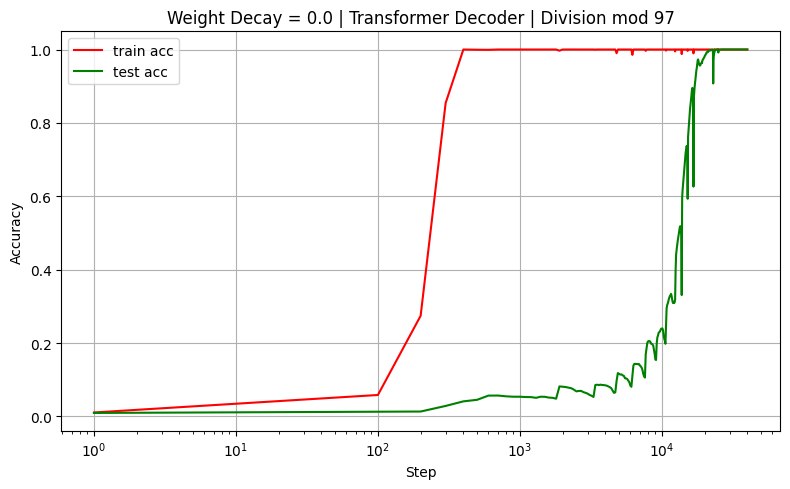

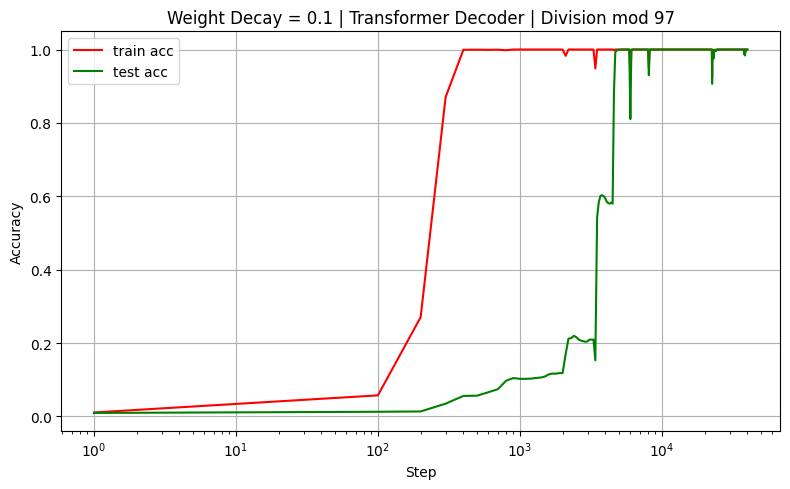

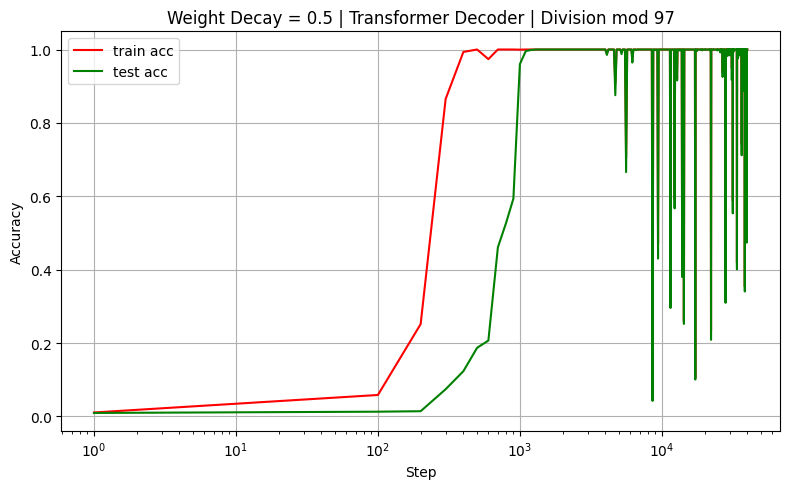

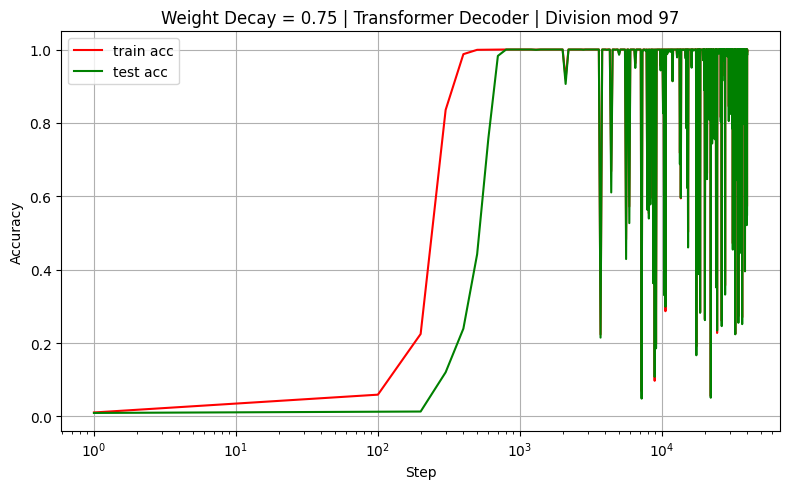

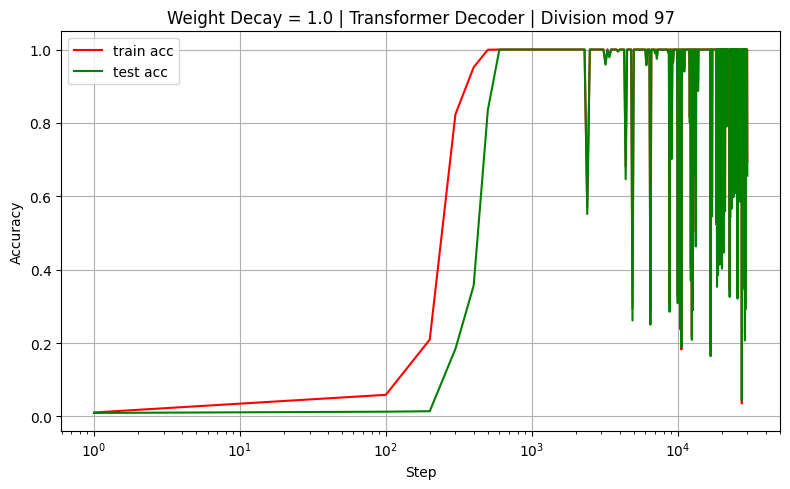

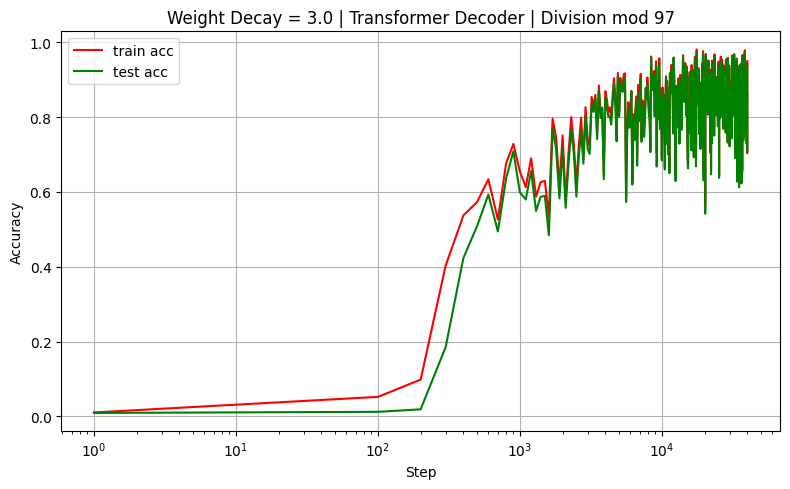

saved to figures/


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

os.makedirs('figures', exist_ok=True)

wd_values = [0.0, 0.1, 0.5, 0.75, 1.0, 3.0]

for wd in wd_values:
    files = glob.glob('results/**/metrics.csv', recursive=True)
    match = [f for f in files if f'wd{wd}' in f]
    if not match:
        print(f'missing: wd={wd}')
        continue
    df = pd.read_csv(match[0])

    plt.figure(figsize=(8, 5))
    plt.plot(df['step'], df['train_acc'], label='train acc', color='red')
    plt.plot(df['step'], df['test_acc'], label='test acc', color='green')
    plt.xscale('log')
    plt.xlabel('Step')
    plt.ylabel('Accuracy')
    plt.title(f'Weight Decay = {wd} | Transformer Decoder | Division mod 97')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'figures/wd_{wd}.png', dpi=150)
    plt.show()
    plt.close()

print('saved to figures/')

/tmp/ipykernel_2076/4167358698.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


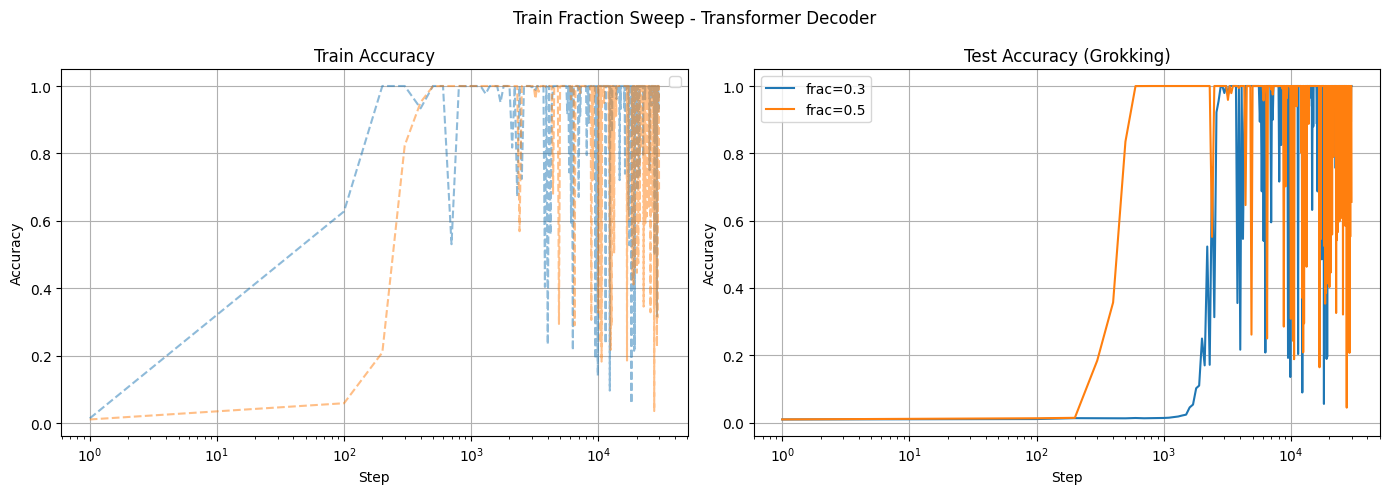

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for frac in [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]:
    files = glob.glob('results/**/metrics.csv', recursive=True)
    match = [f for f in files if f'frac{frac}' in f]
    if not match:
        continue
    df = pd.read_csv(match[0])
    axes[0].plot(df['step'], df['train_acc'], linestyle='--', alpha=0.5)
    axes[1].plot(df['step'], df['test_acc'], label=f'frac={frac}')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('Step')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

axes[0].set_title('Train Accuracy')
axes[1].set_title('Test Accuracy (Grokking)')
plt.suptitle('Train Fraction Sweep - Transformer Decoder')
plt.tight_layout()
plt.show()

### Transformer on Text

In [8]:
!pip install -q datasets

In [9]:
!sed -i 's|load_dataset("CogComp/trec", split="train", trust_remote_code=True)|load_dataset("SetFit/TREC-QC", split="train")|g' data/text_classification.py

# verify
!grep "load_dataset" data/text_classification.py

        from datasets import load_dataset
    raw = load_dataset("SetFit/TREC-QC", split="train")


In [10]:
!grep "coarse" data/text_classification.py

6 coarse-grained question categories:
NUM_CLASSES = 6   # TREC coarse labels
        - TREC coarse labels: 0=ABBR, 1=ENTY, 2=DESC, 3=HUM, 4=LOC, 5=NUM
    labels = [ex['label_coarse'] for ex in raw]


In [11]:
!sed -i "s|ex\['coarse_label'\]|ex['label_coarse']|g" data/text_classification.py
!grep "coarse" data/text_classification.py

6 coarse-grained question categories:
NUM_CLASSES = 6   # TREC coarse labels
        - TREC coarse labels: 0=ABBR, 1=ENTY, 2=DESC, 3=HUM, 4=LOC, 5=NUM
    labels = [ex['label_coarse'] for ex in raw]


In [12]:
# fix trec
!sed -i 's|load_dataset("CogComp/trec", split="train", trust_remote_code=True)|load_dataset("SetFit/TREC-QC", split="train")|g' data/text_classification.py
!sed -i "s|ex\['coarse_label'\]|ex['label_coarse']|g" data/text_classification.py

# fix encoder padding_mask
!sed -i 's|def forward(self, x):|def forward(self, x, padding_mask=None):|g' models/transformer_encoder.py

# verify both
!grep "load_dataset" data/text_classification.py
!grep "def forward" models/transformer_encoder.py

        from datasets import load_dataset
    raw = load_dataset("SetFit/TREC-QC", split="train")
    def forward(self, x, padding_mask=None):
    def forward(self, x, padding_mask=None):


In [13]:
!git config --global user.email "plwdremington@example.com"
!git config --global user.name "pwang1092"
!git remote set-url origin https://github.com/rn-1/GAMBL.git

In [14]:
!git add data/text_classification.py models/transformer_encoder.py
!git commit -m "fix: SetFit/TREC-QC, encoder padding_mask"
!git push origin peter-new

On branch peter-new
Your branch is up to date with 'origin/peter-new'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/__pycache__/__init__.cpython-312.pyc
	data/__pycache__/csv_dataset.cpython-312.pyc
	data/__pycache__/modular_arithmetic.cpython-312.pyc
	data/__pycache__/scan_dataset.cpython-312.pyc
	data/__pycache__/text_classification.cpython-312.pyc
	data/__pycache__/text_datasets.cpython-312.pyc
	figures/
	models/__pycache__/__init__.cpython-312.pyc
	models/__pycache__/mlp.cpython-312.pyc
	models/__pycache__/transformer.cpython-312.pyc
	models/__pycache__/transformer_decoder.cpython-312.pyc
	models/__pycache__/transformer_encoder.cpython-312.pyc

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date


In [15]:
!python train.py --model transformer_encoder \
    --dataset trec \
    --n_steps 100000 \
    --dropout 0.0 \
    --batch_size 512 \
    --weight_decay 1.0

Experiment: transformer_encoder_trec_wd1.0_frac0.5_seed42
Results dir: results/transformer_encoder_trec_wd1.0_frac0.5_seed42
Device: cuda
README.md: 100% 278/278 [00:00<00:00, 1.71MB/s]
Repo card metadata block was not found. Setting CardData to empty.
train.jsonl: 100% 1.27M/1.27M [00:01<00:00, 1.04MB/s]
test.jsonl: 100% 109k/109k [00:00<00:00, 179kB/s]
Generating train split: 100% 5452/5452 [00:00<00:00, 347279.99 examples/s]
Generating test split: 100% 500/500 [00:00<00:00, 208443.69 examples/s]
Train size: 2726, Test size: 2726, Vocab size: 97, Output dim: 6
Model: transformer_encoder, Parameters: 418,182
step=      1 | train_loss=1.6490 train_acc=0.2902 | test_loss=1.6502 test_acc=0.2861 | elapsed=0s
step=    100 | train_loss=0.5373 train_acc=0.8092 | test_loss=1.0183 test_acc=0.6412 | elapsed=2s
step=    200 | train_loss=0.2154 train_acc=0.9277 | test_loss=1.2999 test_acc=0.6647 | elapsed=3s
step=    300 | train_loss=0.0668 train_acc=0.9773 | test_loss=1.5933 test_acc=0.6643 | el

### SCAN dataset

In [16]:
# verify
!python -c "from data.scan_dataset import get_scan_datasets; tr,te,v,c = get_scan_datasets(); print(f'train={len(tr)}, test={len(te)}, vocab={v}, classes={c}')"

SCAN: 1176 pairs, 528 classes, vocab=14
train=588, test=588, vocab=14, classes=528


In [17]:
# verify
!python -c "from data.scan_dataset import get_scan_datasets; tr,te,v,c = get_scan_datasets(); print(f'train={len(tr)}, test={len(te)}, vocab={v}, classes={c}')"

SCAN: 1176 pairs, 528 classes, vocab=14
train=588, test=588, vocab=14, classes=528


In [18]:
!python train.py --model transformer_decoder \
    --dataset scan \
    --max_seq_len 16 \
    --n_steps 50000 \
    --dropout 0.0 \
    --batch_size 512 \
    --weight_decay 0.0

Experiment: transformer_decoder_scan_wd0.0_frac0.5_seed42
Results dir: results/transformer_decoder_scan_wd0.0_frac0.5_seed42
Device: cuda
SCAN: 1176 pairs, 528 classes, vocab=14
Train size: 588, Test size: 588, Vocab size: 14, Output dim: 528
Model: transformer_decoder, Parameters: 468,752
step=      1 | train_loss=6.2017 train_acc=0.0085 | test_loss=6.3195 test_acc=0.0051 | elapsed=0s
step=    100 | train_loss=1.4498 train_acc=0.8741 | test_loss=5.4164 test_acc=0.0612 | elapsed=1s
step=    200 | train_loss=0.0978 train_acc=1.0000 | test_loss=5.8930 test_acc=0.1003 | elapsed=2s
step=    300 | train_loss=0.0182 train_acc=1.0000 | test_loss=6.3093 test_acc=0.0986 | elapsed=3s
step=    400 | train_loss=0.0054 train_acc=1.0000 | test_loss=6.6684 test_acc=0.0986 | elapsed=3s
step=    500 | train_loss=0.0017 train_acc=1.0000 | test_loss=7.0248 test_acc=0.0986 | elapsed=4s
step=    600 | train_loss=0.0006 train_acc=1.0000 | test_loss=7.3947 test_acc=0.0952 | elapsed=5s
step=    700 | train_lo

In [19]:
with open('models/transformer_encoder.py', 'r') as f:
    content = f.read()

content = content.replace(
    'def forward(self, x):',
    'def forward(self, x, padding_mask=None):'
)

with open('models/transformer_encoder.py', 'w') as f:
    f.write(content)

In [20]:
!python train.py --model transformer_encoder \
    --dataset scan \
    --max_seq_len 16 \
    --n_steps 50000 \
    --dropout 0.0 \
    --batch_size 512 \
    --weight_decay 3.0

Experiment: transformer_encoder_scan_wd3.0_frac0.5_seed42
Results dir: results/transformer_encoder_scan_wd3.0_frac0.5_seed42
Device: cuda
SCAN: 1176 pairs, 528 classes, vocab=14
Train size: 588, Test size: 588, Vocab size: 14, Output dim: 528
Model: transformer_encoder, Parameters: 468,752
step=      1 | train_loss=6.2185 train_acc=0.0085 | test_loss=6.3231 test_acc=0.0051 | elapsed=0s
step=    100 | train_loss=2.9147 train_acc=0.6582 | test_loss=5.3834 test_acc=0.0544 | elapsed=1s
step=    200 | train_loss=1.7208 train_acc=0.8622 | test_loss=5.3147 test_acc=0.1020 | elapsed=2s
step=    300 | train_loss=1.3419 train_acc=0.9167 | test_loss=5.5273 test_acc=0.1020 | elapsed=3s
step=    400 | train_loss=1.2159 train_acc=0.9473 | test_loss=5.6426 test_acc=0.1310 | elapsed=3s
step=    500 | train_loss=1.1947 train_acc=0.9609 | test_loss=5.7166 test_acc=0.1327 | elapsed=4s
step=    600 | train_loss=1.1891 train_acc=0.9592 | test_loss=5.8414 test_acc=0.1344 | elapsed=5s
step=    700 | train_lo

### 2 class entailment

In [21]:
from datasets import load_dataset
raw = load_dataset('tasksource/ruletaker', split='train')
print(f"Total: {len(raw)}")

depth1 = [ex for ex in raw if ex['config'] == 'depth-1']
depth2 = [ex for ex in raw if ex['config'] == 'depth-2']
print(f"depth-1: {len(depth1)}, depth-2: {len(depth2)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-52adaa842dd7ed(…):   0%|          | 0.00/28.6M [00:00<?, ?B/s]

data/test-00000-of-00001-402c217dbcd0259(…):   0%|          | 0.00/3.72M [00:00<?, ?B/s]

data/dev-00000-of-00001-480b21836eb3db96(…):   0%|          | 0.00/1.85M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/480152 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/151911 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/75872 [00:00<?, ? examples/s]

Total: 480152
depth-1: 61699, depth-2: 62331


In [22]:
with open('data/ruletaker_dataset.py', 'r') as f:
    content = f.read()

new_load = '''    fetch = max_examples * 5 if (depth or max_context_words) else max_examples
    raw = load_dataset("tasksource/ruletaker", split=f"train[:{fetch}]")'''

new_load_fixed = '''    raw = load_dataset("tasksource/ruletaker", split="train")'''

content = content.replace(new_load, new_load_fixed)

# fix depth filter to support + syntax
content = content.replace(
    '    if depth is not None:\n        raw = raw.filter(lambda ex: ex[\'config\'] == depth)\n        print(f"After depth={depth} filter: {len(raw)} examples")',
    '''    if depth is not None:
        depths = [d.strip() for d in depth.split('+')]
        raw = raw.filter(lambda ex: ex['config'] in depths)
        print(f"After depth={depths} filter: {len(raw)} examples")'''
)

with open('data/ruletaker_dataset.py', 'w') as f:
    f.write(content)

print("done")

done


In [23]:
!pip install -q transformers

!python train.py --model transformer_encoder \
    --dataset text \
    --hf_dataset rte \
    --max_seq_len 128 \
    --n_steps 100000 \
    --dropout 0.0 \
    --batch_size 512 \
    --weight_decay 1.0

Experiment: transformer_encoder_text_wd1.0_frac0.5_seed42
Results dir: results/transformer_encoder_text_wd1.0_frac0.5_seed42
Device: cuda
Traceback (most recent call last):
  File "/content/GAMBL/train.py", line 424, in <module>
    train(args)
  File "/content/GAMBL/train.py", line 321, in train
    train_ds, test_ds, vocab_size, output_dim, seq_len = build_datasets(args)
                                                         ^^^^^^^^^^^^^^^^^^^^
  File "/content/GAMBL/train.py", line 239, in build_datasets
    raise ValueError(f"Unknown dataset: {args.dataset}")
ValueError: Unknown dataset: text


### Analogies

In [24]:
for wd in [0.0, 0.1, 0.5, 0.75, 1.0, 3.0]:
    !python train.py --model transformer_decoder \
        --dataset csv \
        --csv_path data/questions-words.csv \
        --n_steps 30000 \
        --dropout 0.0 \
        --batch_size 512 \
        --weight_decay {wd}

Experiment: transformer_decoder_csv_wd0.0_frac0.5_seed42
Results dir: results/transformer_decoder_csv_wd0.0_frac0.5_seed42
Device: cuda
Train size: 19544, Test size: 19544, Vocab size: 474, Output dim: 506
Model: transformer_decoder, Parameters: 522,874
step=      1 | train_loss=6.0789 train_acc=0.0403 | test_loss=6.0790 test_acc=0.0400 | elapsed=0s
step=    100 | train_loss=0.3487 train_acc=0.8771 | test_loss=0.3486 test_acc=0.8770 | elapsed=1s
step=    200 | train_loss=0.2285 train_acc=0.8758 | test_loss=0.2286 test_acc=0.8757 | elapsed=2s
step=    300 | train_loss=0.1984 train_acc=0.8765 | test_loss=0.1983 test_acc=0.8764 | elapsed=3s
step=    400 | train_loss=0.1966 train_acc=0.8751 | test_loss=0.1965 test_acc=0.8750 | elapsed=4s
step=    500 | train_loss=0.1914 train_acc=0.8754 | test_loss=0.1913 test_acc=0.8753 | elapsed=5s
step=    600 | train_loss=0.1889 train_acc=0.8757 | test_loss=0.1887 test_acc=0.8759 | elapsed=5s
step=    700 | train_loss=0.1881 train_acc=0.8765 | test_los

### LOGIC

In [25]:
with open('data/ruletaker_dataset.py', 'r') as f:
    content = f.read()

new_load = '''    fetch = max_examples * 5 if (depth or max_context_words) else max_examples
    raw = load_dataset("tasksource/ruletaker", split=f"train[:{fetch}]")'''

new_load_fixed = '''    raw = load_dataset("tasksource/ruletaker", split="train")'''

content = content.replace(new_load, new_load_fixed)

# fix depth filter to support + syntax
content = content.replace(
    '    if depth is not None:\n        raw = raw.filter(lambda ex: ex[\'config\'] == depth)\n        print(f"After depth={depth} filter: {len(raw)} examples")',
    '''    if depth is not None:
        depths = [d.strip() for d in depth.split('+')]
        raw = raw.filter(lambda ex: ex['config'] in depths)
        print(f"After depth={depths} filter: {len(raw)} examples")'''
)

with open('data/ruletaker_dataset.py', 'w') as f:
    f.write(content)

print("done")

done


In [26]:
from datasets import load_dataset
import numpy as np

raw = load_dataset('tasksource/ruletaker', split='train')
depths = ['depth-0','depth-1', 'depth-2']
filtered = [ex for ex in raw if ex['config'] in depths]
short = [ex for ex in filtered if len(ex['context'].split()) <= 20]

print(f"depth 0 to 2 total: {len(filtered)}")
print(f"after max_context_words=15: {len(short)}")
print(f"after max_examples=7000 cap: {min(7000, len(short))}")
print(f"train size: {int(min(7000, len(short)) * 0.5)}")
print(f"\nSample contexts:")
for ex in short[:3]:
    words = ex['context'].split()
    print(f"  [{len(words)} words] {ex['context']}")

depth 0 to 2 total: 184587
after max_context_words=15: 5544
after max_examples=7000 cap: 5544
train size: 2772

Sample contexts:
  [19 words] Bob is furry. Charlie is furry. Harry is not green. If someone is not kind then they are quiet.
  [19 words] Bob is furry. Charlie is furry. Harry is not green. If someone is not kind then they are quiet.
  [19 words] Bob is furry. Charlie is furry. Harry is not green. If someone is not kind then they are quiet.


In [27]:
for wd in [0.0, 0.1]:
    !python train.py --model transformer_encoder \
      --dataset ruletaker \
      --ruletaker_depth "depth-0+depth-1+depth-2" \
      --ruletaker_max_examples 7000 \
      --ruletaker_max_context_words 20 \
      --max_seq_len 64 \
      --n_steps 300000 \
      --dropout 0.0 \
      --batch_size 512 \
      --weight_decay {wd}

Streaming output truncated to the last 5000 lines.
step= 101700 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5586 test_acc=0.5440 | elapsed=1265s
step= 101800 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5590 test_acc=0.5440 | elapsed=1267s
step= 101900 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5594 test_acc=0.5440 | elapsed=1268s
step= 102000 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5599 test_acc=0.5440 | elapsed=1269s
step= 102100 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5603 test_acc=0.5440 | elapsed=1270s
step= 102200 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5607 test_acc=0.5440 | elapsed=1272s
step= 102300 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5611 test_acc=0.5440 | elapsed=1273s
step= 102400 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5615 test_acc=0.5440 | elapsed=1274s
step= 102500 | train_loss=0.0000 train_acc=1.0000 | test_loss=11.5620 test_acc=0.5440 | elapsed=1275s
step= 102600 | train_loss=0.000